In [1]:
from mipt import *
import numpy as np
import importlib
import gilbert

importlib.reload(gilbert)

from gilbert import HybridUQNBank3Q, gilbert_uqn_distance_3q

bank = HybridUQNBank3Q.load(
    "uqn_hybrid_bank.pt",
    device="cuda",
    dtype="complex64",
)

backend = AerSimulator(device="CPU", method="matrix_product_state")

n = 8
d = 2 * n
p_values = np.linspace(0.0, 1.0, 21)
circuit_reps = 10

means = []
stderrs = []

for p in p_values:
    Ds = []
    print(f"Simulating p={p:.3f}...")

    for rep in range(circuit_reps):
        # New unitary disorder and new measurement-location disorder every rep.
        qc = random_mipt_1d(n=n, d=d, p=float(p), closed=True)

        qc.save_density_matrix(
            qubits=[0, 1, 2],
            label="final_state",
            pershot=True,
        )

        tqc = transpile(qc, backend)

        # One conditional outcome trajectory for this independently drawn circuit.
        result = backend.run(tqc, shots=1).result()
        sub_m = result.data(0)["final_state"][0]

        res = gilbert_uqn_distance_3q(
            sub_m,
            bank=bank,
            input_order="qiskit",
            qiskit_qubit_order=(0, 1, 2),

            max_iter=36,
            memory=24,
            topk_per_family=2,
            fresh_starts_per_family=0,
            fast_families_to_refine=1,
            fast_refinement_steps=8,
            families_to_refine=4,
            refinement_steps=24,
            full_refine_every=8,
            memory_update_every=4,
            local_cache_size=24,

            bs_max_iter=80,
            bs_memory=40,
            bs_restarts=4,
            bs_sweeps=8,
            bs_initial_random_atoms=8,

            cache_refined_atoms=False,
            seed=100000 * rep + int(round(10000 * p)),
        )

        Ds.append(res.distance)

    Ds = np.asarray(Ds, dtype=float)
    mean = float(np.mean(Ds))
    stderr = float(np.std(Ds, ddof=1) / np.sqrt(len(Ds)))

    means.append(mean)
    stderrs.append(stderr)

    print(f"p={p:.3f}, D={mean:.8g} ± {stderr:.3g}")

Simulating p=0.000...
p=0.000, D=3.5323057e-05 ± 1.48e-05
Simulating p=0.050...
p=0.050, D=0.0032626148 ± 0.000853
Simulating p=0.100...
p=0.100, D=0.01012164 ± 0.00283
Simulating p=0.150...
p=0.150, D=0.0069225606 ± 0.00176
Simulating p=0.200...
p=0.200, D=0.015162677 ± 0.00849
Simulating p=0.250...
p=0.250, D=0.01366766 ± 0.00512
Simulating p=0.300...
p=0.300, D=0.032099374 ± 0.0223
Simulating p=0.350...
p=0.350, D=0.0091212916 ± 0.0034
Simulating p=0.400...
p=0.400, D=0.0044692397 ± 0.00062
Simulating p=0.450...
p=0.450, D=0.0042547483 ± 0.000793
Simulating p=0.500...
p=0.500, D=0.0040800962 ± 0.000961
Simulating p=0.550...
p=0.550, D=0.0034050124 ± 0.000974
Simulating p=0.600...
p=0.600, D=0.0027299988 ± 0.00048
Simulating p=0.650...
p=0.650, D=0.0020464185 ± 0.000645
Simulating p=0.700...
p=0.700, D=0.0027576173 ± 0.000726
Simulating p=0.750...
p=0.750, D=0.002640162 ± 0.000979
Simulating p=0.800...
p=0.800, D=0.001351871 ± 0.000396
Simulating p=0.850...
p=0.850, D=0.00079939345 ±

In [1]:
from mipt import *
from gnme import random_pure_triangle_uqn_state_6q, gjk

n=8
d=2*n
ps = np.linspace(0.0, 1.0, 11)

backend = AerSimulator(device="CPU", method="matrix_product_state")

ds = []
gmns = []
for p in ps:
    qc = random_mipt_1d(n=n, d=d, p=float(p), closed=True)

    qc.save_density_matrix(
        qubits=[0, 1, 2, 3, 4, 5],
        label="final_state",
        pershot=True,
    )

    tqc = transpile(qc, backend)

    # One conditional outcome trajectory for this independently drawn circuit.
    result = backend.run(tqc, shots=1).result()
    sub_m = result.data(0)["final_state"][0]

    psi, rho_init = random_pure_triangle_uqn_state_6q(np.random.default_rng(5678))

    this_gmn = gmn(sub_m, parties=6)
    print(f"p = {p:.2f} GMN: {this_gmn:.8g}")
    gmns.append(this_gmn)

    # print("norm:", np.vdot(psi, psi).real)
    # print("trace:", np.trace(rho_init).real)
    # print("rank:", np.linalg.matrix_rank(rho_init, tol=1e-10))
    # print("shape:", rho_init.shape)


    dist, rho_approx, info = gjk(
        sub_m,
        rho_init,
        seed=1234,
        tol=1e-8,
        max_trials=1_000,
        max_accepts=500
    )

    ds.append(dist)
    print(f"p = {p:.2f} final distance: {dist}")
    print(info)

plt.scatter(ps, ds, color="black")
plt.scatter(ps, gmns, color="red")

trials=331, accepted=260, D=0.432929933133, improvement=1.489e-10        
Final distance: 0.4329299331333366
{'trials': 331, 'accepted': 260, 'rejected_score': 0, 'rejected_degenerate': 0, 'final_d2': 0.1874283270028353, 'final_distance': 0.4329299331333366, 'acceptance_rate': 0.7854984894259819}
trials=357, accepted=220, D=0.546253624626, improvement=1.932e-05        
Final distance: 0.5452478103364496
{'trials': 381, 'accepted': 227, 'rejected_score': 0, 'rejected_degenerate': 0, 'final_d2': 0.297295174676693, 'final_distance': 0.5452478103364496, 'acceptance_rate': 0.5958005249343832}
trials=173, accepted=160, D=0.446643447294, improvement=8.425e-05        
Final distance: 0.4465061097268186
{'trials': 180, 'accepted': 165, 'rejected_score': 0, 'rejected_degenerate': 0, 'final_d2': 0.19936770602337775, 'final_distance': 0.4465061097268186, 'acceptance_rate': 0.9166666666666666}
trials=980, accepted=190, D=0.502212418395, improvement=2.090e-07        
Final distance: 0.49714596841012

KeyboardInterrupt: 

In [1]:
from mipt import *
from gmn import CompiledGMNSDP, gmn_fast

n=8
d=2*n
ps = np.linspace(0.0, 0.7, 8)
reps = 5
subsyst = 4

compiled = CompiledGMNSDP(
    dims=[2] * subsyst,
    formulation="monotone",
    real=True,
)

backend = AerSimulator(device="CPU", method="matrix_product_state")

rhos = {}

print("Starting circuit simulations...")

for p in ps:
    rhos[str(p)] = []
    for _ in range(reps):
        qc = random_mipt_1d(n=n, d=d, p=float(p), closed=True)

        qc.save_density_matrix(
            qubits=list(range(subsyst)),
            label="final_state",
            pershot=True,
        )

        tqc = transpile(qc, backend)

        # One conditional outcome trajectory for this independently drawn circuit.
        result = backend.run(tqc, shots=1).result()
        sub_m = result.data(0)["final_state"][0]
        rhos[str(p)].append(sub_m)

print("Starting GMN computations...")

means = []
errs = []
for p in ps:
    print(f"p={p:.3f}...")
    gmns = []
    for _ in range(reps):

        sub_m = rhos[str(p)].pop()

        score = gmn_fast(
            sub_m,
            formulation="monotone",
        )
        gmns.append(float(score))

    means.append(np.mean(gmns))
    errs.append(np.std(gmns))
    print(f"p={p:.3f}, GMN={means[-1]:.8g} ± {errs[-1]:.3g}")

plt.errorbar(ps, means, yerr=errs, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)

Starting circuit simulations...
Starting GMN computations...
p=0.000...


KeyboardInterrupt: 

In [ ]:
from mipt import *
from collections import defaultdict
from read_mipt_rho3 import read_rho3_bin
import warnings
import numpy as np
from collections import defaultdict
import importlib
import gnme
importlib.reload(gnme)
from gnme import RingInflationSDP3Q

warnings.filterwarnings('ignore', category=UserWarning)

sdp = RingInflationSDP3Q()


def scan_func_by_p(records, func, limit=None):
    """
    Compute mean ± sample stddev of a given function at each p.

    Parameters
    ----------
    records : list[dict]
        Output from read_rho3_bin(...).

    func : callable
        Function taking one 8x8 density matrix and returning a scalar.

    limit : int | None
        Maximum number of matrices to evaluate for each p.
        If None, all matrices are used.

    Returns
    -------
    results : dict[float, dict]
    """

    if limit is not None:
        if not isinstance(limit, int):
            raise TypeError("limit must be an int or None.")
        if limit <= 0:
            raise ValueError("limit must be positive when provided.")

    grouped = defaultdict(list)

    for rec in records:
        grouped[float(rec["p"])].append(rec)

    results = {}

    for p in sorted(grouped):
        group = grouped[p]

        if limit is not None:
            group = group[:limit]

        values = np.asarray(
            [
                float(np.real_if_close(func(rec["rho"])))
                for rec in group
            ],
            dtype=float,
        )

        results[p] = {
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
            "n": int(len(values)),
            "values": values,
        }

    return results

def mixed_ghz_3q(p):
    # Define the basis states
    ket0 = np.array([1, 0])
    ket1 = np.array([0, 1])

    # |000> state = |0> ⊗ |0> ⊗ |0>
    ket000 = np.kron(np.kron(ket0, ket0), ket0)

    # |111> state = |1> ⊗ |1> ⊗ |1>
    ket111 = np.kron(np.kron(ket1, ket1), ket1)

    # 1/sqrt(2) * (|000> + |111>)
    ghz_state = (1 / np.sqrt(2)) * (ket000 + ket111)

    # Density matrix representation: rho = |GHZ><GHZ|
    return (1-p)*np.outer(ghz_state, ghz_state) + p * np.eye(8) / 8


# records = read_rho3_bin("rho3.bin")

# results = scan_func_by_p(records, inflation_score, limit=10)

# for p, stats in results.items():
#     print(
#         f"p={p:.3f}: "
#         f"F_GHZ = {stats['mean']:.6f} ± {stats['std']:.6f} "
#         f"(n={stats['n']})"
#     )

# p_vals = np.array(sorted(results.keys()))
# means = np.array([results[p]["mean"] for p in p_vals])
# stds = np.array([results[p]["std"] for p in p_vals])
# ns = np.array([results[p]["n"] for p in p_vals])

n=4
d=2*n
ps = np.linspace(0.0, 0.5, 21)
reps = 10

means, stderrs = [], []
for p in ps:
    # print(f"Simulating p = {p:.2f}", end='', flush=True)
    scores = []
    for _ in range(reps):
        rho = get_mipt_rho_1d(n, d, p, subsyst=3, closed=True)
        score = sdp.solve(rho, gpu=False, verbose=True, max_iters=2_500)

        scores.append(score)
        # print(".", end='', flush=True)
    means.append(np.mean(scores))
    stderrs.append(np.std(scores)/np.sqrt(reps))
    print(f"\nInflation Score: {means[-1]:.8g} ± {stderrs[-1]:.3g}")

plt.errorbar(ps, [1 - m for m in means], yerr=stderrs, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
plt.xlabel("p")
plt.ylabel("Adj. Inflation Score $1-s$")
plt.show()

(CVXPY) Jun 08 02:07:18 PM: Your problem has 8193 variables, 17664 constraints, and 64 parameters.
(CVXPY) Jun 08 02:07:18 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jun 08 02:07:18 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jun 08 02:07:18 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jun 08 02:07:18 PM: Compiling problem (target solver=SCS).
(CVXPY) Jun 08 02:07:18 PM: Reduction chain: EvalParams -> Complex2Real -> FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Jun 08 02:07:18 PM: Applying reduction EvalParams
(CVXPY) Jun 08 02:07:18 PM: Applying reduction Complex2Real
(CVXPY) Jun 08 02:07:18 PM: Applying reduction FlipObjective
(CVXPY) Jun 08 02:07:18 PM: Applying reduction Dcp2Cone


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jun 08 02:07:19 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jun 08 02:07:19 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Jun 08 02:07:19 PM: Applying reduction SCS
(CVXPY) Jun 08 02:07:19 PM: Finished problem compilation (took 7.958e-01 seconds).
(CVXPY) Jun 08 02:07:19 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 8193, constraints m: 35380
cones: 	  z: primal zero / dual free vars: 9026
	  l: linear vars: 2
	  s: psd vars: 26352, ssize: 6
settings: eps_abs: 1.0e-04, eps_rel: 1.0e-04, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 10000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 53530, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res 

SolverError: Solver 'SCS' failed. Try another solver, or solve with verbose=True for more information.

: 

In [7]:
from numpy.typing import NDArray
ComplexVector = NDArray[np.complex128]
ComplexMatrix = NDArray[np.complex128]
from gnme import inflation_score
import numpy as np

def ket0():
    return np.array([1, 0], dtype=np.complex128)


def ket1():
    return np.array([0, 1], dtype=np.complex128)


def dm(psi):
    psi = np.asarray(psi, dtype=np.complex128)
    return np.outer(psi, psi.conj())


def normalize(psi):
    psi = np.asarray(psi, dtype=np.complex128)
    return psi / np.linalg.norm(psi)


def kron_all(*ops):
    out = np.array([[1]], dtype=np.complex128)
    for op in ops:
        out = np.kron(out, op)
    return out


def pure_product_abc(a, b, c):
    psi = np.kron(np.kron(a, b), c)
    return dm(psi)


def bell_phi_plus():
    return normalize(np.array([1, 0, 0, 1], dtype=np.complex128))


def ghz3():
    psi = np.zeros(8, dtype=np.complex128)
    psi[0] = 1 / np.sqrt(2)
    psi[7] = 1 / np.sqrt(2)
    return dm(psi)


def w3():
    psi = np.zeros(8, dtype=np.complex128)
    psi[1] = 1 / np.sqrt(3)  # |001>
    psi[2] = 1 / np.sqrt(3)  # |010>
    psi[4] = 1 / np.sqrt(3)  # |100>
    return dm(psi)


def white_mix(rho, p):
    """
    rho_p = (1-p) rho + p I/d
    where p is the white-noise fraction.
    """
    d = rho.shape[0]
    return (1 - p) * rho + p * np.eye(d, dtype=np.complex128) / d


def bell_ab_product_c():
    """
    |Phi+>_AB tensor |0>_C
    in output order A,B,C.
    """
    bell = bell_phi_plus()  # order A,B
    c = ket0()

    psi = np.kron(bell, c)  # AB,C -> A,B,C
    return dm(psi)


def bell_ac_product_b():
    """
    |Phi+>_AC tensor |0>_B
    output order A,B,C.
    """
    psi = np.zeros(8, dtype=np.complex128)

    # (|00>_AC + |11>_AC)/sqrt(2) tensor |0>_B
    # output order A,B,C:
    # A=0,B=0,C=0 -> |000>
    # A=1,B=0,C=1 -> |101>
    psi[0b000] = 1 / np.sqrt(2)
    psi[0b101] = 1 / np.sqrt(2)

    return dm(psi)


def bell_bc_product_a():
    """
    |0>_A tensor |Phi+>_BC
    output order A,B,C.
    """
    a = ket0()
    bell = bell_phi_plus()  # order B,C

    psi = np.kron(a, bell)  # A,BC -> A,B,C
    return dm(psi)

rho_000 = pure_product_abc(ket0(), ket0(), ket0())
rho_111 = pure_product_abc(ket1(), ket1(), ket1())

print("product |000>:", inflation_score(rho_000, verbose=False))
print("product |111>:", inflation_score(rho_111, verbose=False))

tests = {
    "Bell_AB x |0>_C": bell_ab_product_c(),
    "Bell_AC x |0>_B": bell_ac_product_b(),
    "Bell_BC x |0>_A": bell_bc_product_a(),
}

for name, rho in tests.items():
    val = inflation_score(rho, verbose=False)
    print(f"{name:20s}  t_max = {val:.8f}")

rho_bisep_mix = (
    0.25 * bell_ab_product_c()
    + 0.35 * bell_ac_product_b()
    + 0.40 * bell_bc_product_a()
)

print("mixed biseparable network:", inflation_score(rho_bisep_mix, verbose=False))

product |000>: 0.9999999891136315
product |111>: 0.9999999891136175
Bell_AB x |0>_C       t_max = 0.99999205
Bell_AC x |0>_B       t_max = 0.99999205
Bell_BC x |0>_A       t_max = 0.99999207
mixed biseparable network: 1


[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[0.9999997816310657, 0.9999998887121778, 0.9999996008436393, 0.9999999499867709, 0.9999991118051959, 0.9999988551294703, 0.9999999824400035, 0.9999999939088525, 0.9999998670153671, 0.9999999891925295, 0.9999999891136186]


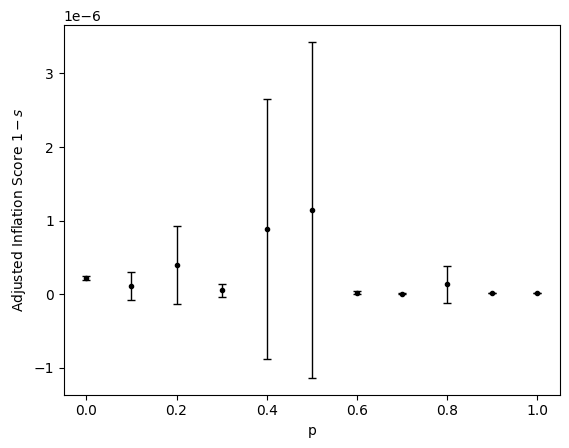

In [ ]:

plt.errorbar(ps, [1 - m for m in means], yerr=stderrs, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
print("ps:", ps)
print("mean scores:", [float(m) for m in means])
plt.xlabel("p")
plt.ylabel("Adjusted Inflation Score $1 - s$")
plt.show()

In [11]:
def haar_unitary(dim, rng):
    z = rng.normal(size=(dim, dim)) + 1j * rng.normal(size=(dim, dim))
    q, r = np.linalg.qr(z)

    diag = np.diag(r)
    phases = np.ones(dim, dtype=np.complex128)
    nz = np.abs(diag) > 0
    phases[nz] = diag[nz] / np.abs(diag[nz])

    return q * phases.conj()


def apply_unitary_to_subsystems_statevec(psi, U, targets, dims):
    """
    Apply U to selected subsystems of a pure state vector.

    dims:
        subsystem dimensions.

    targets:
        subsystem indices acted on by U, in the order U expects.
    """
    dims = list(dims)
    n = len(dims)
    targets = list(targets)

    psi_t = psi.reshape(dims)

    perm = targets + [i for i in range(n) if i not in targets]
    inv_perm = np.argsort(perm)

    front_dim = int(np.prod([dims[i] for i in targets]))
    back_dim = int(np.prod([dims[i] for i in range(n) if i not in targets]))

    psi_perm = np.transpose(psi_t, perm).reshape(front_dim, back_dim)
    psi_perm = U @ psi_perm

    psi_out = psi_perm.reshape([dims[i] for i in perm])
    psi_out = np.transpose(psi_out, inv_perm)

    return psi_out.reshape(-1)


def partial_trace_numeric(rho, dims, keep):
    """
    Numeric ordered marginal, keeping subsystems in the listed order.
    """
    dims = list(dims)
    keep = list(keep)
    n = len(dims)

    trace = [i for i in range(n) if i not in keep]

    T = rho.reshape(*dims, *dims)
    current_dims = list(dims)

    for s in sorted(trace, reverse=True):
        T = np.trace(T, axis1=s, axis2=s + len(current_dims))
        current_dims.pop(s)

    remaining = [i for i in range(n) if i in keep]

    perm_ket = [remaining.index(i) for i in keep]
    k = len(keep)
    perm = perm_ket + [p + k for p in perm_ket]

    T = np.transpose(T, perm)

    d_keep = int(np.prod([dims[i] for i in keep]))
    return T.reshape(d_keep, d_keep)


def triangle_bell_network_state(seed=0, keep_local=(0, 0, 0)):
    """
    Build a 3-qubit state known to be in the triangle network set.

    Virtual subsystem order:
        [A0, A1, B0, B1, C0, C1]

    Link Bell pairs:
        A0-B0
        B1-C0
        C1-A1

    Local nodes:
        A = [A0, A1] = [0, 1]
        B = [B0, B1] = [2, 3]
        C = [C0, C1] = [4, 5]

    keep_local:
        Which local qubit to keep at each node after the local unitary.
        For example (0,0,0) keeps A0, B0, C0.
    """
    rng = np.random.default_rng(seed)

    dims = [2, 2, 2, 2, 2, 2]
    d = 64

    # Build the 6-qubit state:
    # Bell(A0,B0) Bell(B1,C0) Bell(C1,A1)
    #
    # We fill amplitudes explicitly in virtual order [A0,A1,B0,B1,C0,C1].
    psi = np.zeros(d, dtype=np.complex128)

    for x in [0, 1]:  # A0 = B0
        for y in [0, 1]:  # B1 = C0
            for z in [0, 1]:  # C1 = A1
                A0 = x
                B0 = x

                B1 = y
                C0 = y

                C1 = z
                A1 = z

                bits = [A0, A1, B0, B1, C0, C1]
                idx = 0
                for bit in bits:
                    idx = 2 * idx + bit

                psi[idx] = 1 / np.sqrt(8)

    # Random local unitaries at nodes.
    UA = haar_unitary(4, rng)
    UB = haar_unitary(4, rng)
    UC = haar_unitary(4, rng)

    psi = apply_unitary_to_subsystems_statevec(psi, UA, [0, 1], dims)
    psi = apply_unitary_to_subsystems_statevec(psi, UB, [2, 3], dims)
    psi = apply_unitary_to_subsystems_statevec(psi, UC, [4, 5], dims)

    rho6 = dm(psi)

    # Choose one output qubit from each node.
    A_keep = [0, 1][keep_local[0]]
    B_keep = [2, 3][keep_local[1]]
    C_keep = [4, 5][keep_local[2]]

    rho_abc = partial_trace_numeric(rho6, dims, [A_keep, B_keep, C_keep])

    # Symmetrize tiny numerical noise.
    rho_abc = (rho_abc + rho_abc.conj().T) / 2
    rho_abc = rho_abc / np.trace(rho_abc)

    return rho_abc

for seed in range(5):
    rho_net = triangle_bell_network_state(seed=seed, keep_local=(0, 0, 0))
    val = inflation_score(rho_net, verbose=False)
    print(f"triangle Bell network seed={seed}: t_max = {val:.8f}")

triangle Bell network seed=0: t_max = 1.00000000
triangle Bell network seed=1: t_max = 1.00000000
triangle Bell network seed=2: t_max = 0.99999900
triangle Bell network seed=3: t_max = 0.99999540
triangle Bell network seed=4: t_max = 0.99999994
